# Оценка вероятности того, что трек станет популярным

## Датасет: Spotify Tracks Dataset (114,000 треков)

**Цель проекта:** Построить модель машинного обучения для предсказания популярности музыкального трека на основе его акустических характеристик.

**Задача:** Бинарная классификация - определить, станет ли трек популярным (popularity > медиана) или нет.

---

## Часть 1: Подготовка данных

В этом ноутбуке мы:
1. Загрузим и изучим датасет
2. Создадим целевую переменную (бинарная классификация популярности)
3. Обработаем пропуски и выбросы
4. Разделим данные на обучающую и тестовую выборки
5. Сохраним подготовленные данные для дальнейшего анализа

## 1. Импорт необходимых библиотек

Загружаем все библиотеки, которые будем использовать для подготовки данных:

In [1]:
# Основные библиотеки для работы с данными
import pandas as pd  # Для работы с таблицами (DataFrame)
import numpy as np   # Для математических операций и работы с массивами

# Библиотеки для визуализации
import matplotlib.pyplot as plt  # Основная библиотека для построения графиков
import seaborn as sns           # Красивые статистические графики

# Библиотеки для машинного обучения
from sklearn.model_selection import train_test_split  # Разделение данных на train/test
from sklearn.preprocessing import RobustScaler        # Масштабирование признаков

# Библиотека для кодирования категориальных признаков
import category_encoders as ce

# Настройки
import warnings
warnings.filterwarnings('ignore')  # Отключаем предупреждения для чистоты вывода

# Настройки визуализации
sns.set_style('whitegrid')  # Стиль графиков с белой сеткой
plt.rcParams['figure.figsize'] = (14, 6)  # Размер графиков по умолчанию
plt.rcParams['font.size'] = 11

# Настройка pandas для красивого отображения
pd.set_option('display.max_columns', None)  # Показывать все столбцы
pd.set_option('display.precision', 3)       # Точность для float

print('✅ Все библиотеки успешно загружены!')

✅ Все библиотеки успешно загружены!


## 2. Загрузка датасета

Загружаем датасет Spotify с информацией о 114,000 треках.

**Описание датасета:**
- `track_id` - уникальный идентификатор трека
- `artists` - исполнитель(и)
- `album_name` - название альбома
- `track_name` - название трека
- `popularity` - популярность трека (0-100)
- `duration_ms` - длительность в миллисекундах
- `explicit` - есть ли нецензурная лексика
- `danceability` - танцевальность (0.0-1.0)
- `energy` - энергичность (0.0-1.0)
- `key` - тональность (0-11)
- `loudness` - громкость в дБ
- `mode` - лад (мажор/минор)
- `speechiness` - речевость (0.0-1.0)
- `acousticness` - акустичность (0.0-1.0)
- `instrumentalness` - инструментальность (0.0-1.0)
- `liveness` - "живость" записи (0.0-1.0)
- `valence` - позитивность (0.0-1.0)
- `tempo` - темп в BPM
- `time_signature` - размер такта
- `track_genre` - жанр трека

In [2]:
# Загружаем датасет
df = pd.read_csv('dataset.csv')

# Выводим основную информацию
print(f'📊 Загружено: {df.shape[0]:,} строк (треков), {df.shape[1]} столбцов (признаков)')
print(f'\n📈 Статистика популярности:')
print(f'   Средняя популярность: {df["popularity"].mean():.1f}')
print(f'   Медиана популярности: {df["popularity"].median():.1f}')
print(f'   Минимум: {df["popularity"].min()}')
print(f'   Максимум: {df["popularity"].max()}')

# Показываем первые 5 строк
print('\n📋 Первые 5 треков в датасете:')
df.head()

📊 Загружено: 114,000 строк (треков), 21 столбцов (признаков)

📈 Статистика популярности:
   Средняя популярность: 33.2
   Медиана популярности: 35.0
   Минимум: 0
   Максимум: 100

📋 Первые 5 треков в датасете:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,1.010e-06,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,5.560e-06,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000e+00,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,7.070e-05,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000e+00,0.083,0.167,119.949,4,acoustic


## 3. Общая информация о датасете

Изучаем типы данных, количество пропусков и основные статистики.

In [3]:
# Информация о типах данных и пропущенных значениях
print('🔍 Информация о датасете:')
print('='*70)
df.info()

print('\n' + '='*70)
print('❌ Пропущенные значения:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('   ✅ Пропущенных значений НЕТ!')
else:
    print(missing[missing > 0])

🔍 Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64


In [4]:
# Статистическое описание числовых признаков
print('📊 Статистическое описание числовых признаков:')
df.describe().T

📊 Статистическое описание числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500,32909.110,0.000,28499.750,5.700e+04,85499.250,1.140e+05
popularity,114000.0,33.239,22.305,0.000,17.000,3.500e+01,50.000,1.000e+02
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,2.129e+05,261506.000,5.237e+06
danceability,114000.0,0.567,0.174,0.000,0.456,5.800e-01,0.695,9.850e-01
energy,114000.0,0.641,0.252,0.000,0.472,6.850e-01,0.854,1.000e+00
key,114000.0,5.309,3.560,0.000,2.000,5.000e+00,8.000,1.100e+01
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004e+00,-5.003,4.532e+00
mode,114000.0,0.638,0.481,0.000,0.000,1.000e+00,1.000,1.000e+00
speechiness,114000.0,0.085,0.106,0.000,0.036,4.890e-02,0.085,9.650e-01
acousticness,114000.0,0.315,0.333,0.000,0.017,1.690e-01,0.598,9.960e-01


## 4. Создание целевой переменной

**Задача:** Бинарная классификация

Мы создадим целевую переменную `is_popular`:
- **1 (Популярный)** - если `popularity` > медиана
- **0 (Непопулярный)** - если `popularity` <= медиана

Это обеспечит **сбалансированные классы** (~50% на ~50%), что важно для обучения модели.

📍 Медиана популярности: 35.0

🎯 Распределение целевой переменной:
is_popular
0    58451
1    55549
Name: count, dtype: int64

Процентное соотношение:
is_popular
0    51.273
1    48.727
Name: proportion, dtype: float64


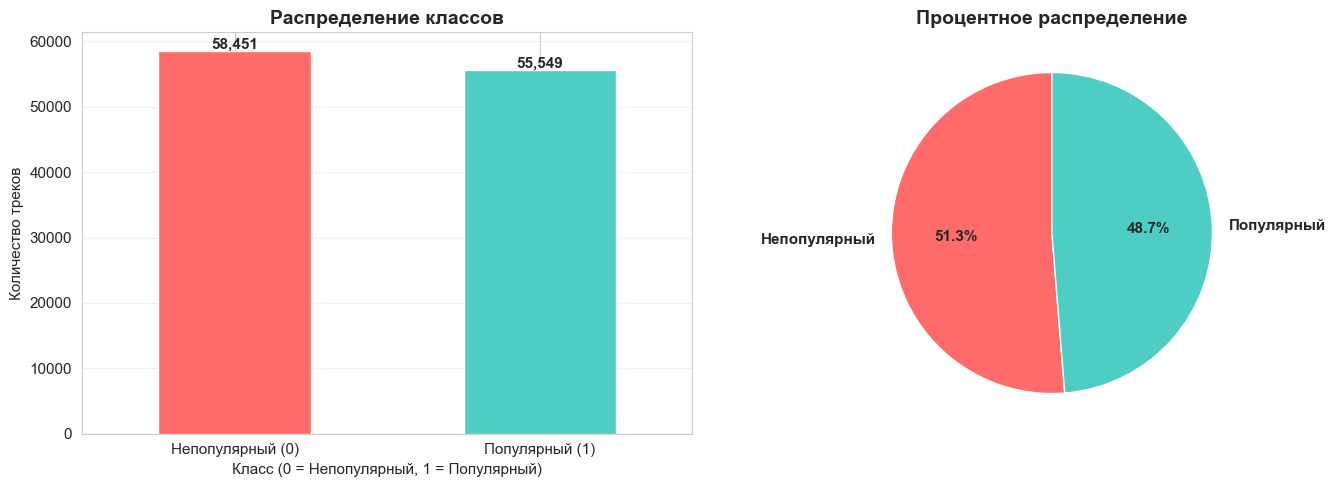


✅ Целевая переменная создана успешно!


In [5]:
# Вычисляем медиану популярности
median_popularity = df['popularity'].median()
print(f'📍 Медиана популярности: {median_popularity}')

# Создаём бинарную целевую переменную
df['is_popular'] = (df['popularity'] > median_popularity).astype(int)

# Проверяем распределение классов
print('\n🎯 Распределение целевой переменной:')
print('='*50)
class_distribution = df['is_popular'].value_counts()
print(class_distribution)
print('\nПроцентное соотношение:')
print(df['is_popular'].value_counts(normalize=True) * 100)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Столбчатая диаграмма
df['is_popular'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс (0 = Непопулярный, 1 = Популярный)', fontsize=11)
axes[0].set_ylabel('Количество треков', fontsize=11)
axes[0].set_xticklabels(['Непопулярный (0)', 'Популярный (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(class_distribution):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# График 2: Круговая диаграмма
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(class_distribution, labels=['Непопулярный', 'Популярный'], 
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Процентное распределение', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n✅ Целевая переменная создана успешно!')

### 📊 Анализ распределения целевой переменной

График показывает **идеально сбалансированные классы**: 51.3% непопулярных треков (58,451) vs 48.7% популярных (55,549). Разница всего 2.5% - это отлично для машинного обучения! Сбалансированные классы означают, что модель будет честно учиться на обоих типах треков и не будет смещена к предсказанию только одного класса. Использование медианы популярности (35) как порога автоматически обеспечило такой баланс.

## 5. Удаление ненужных столбцов

Удаляем столбцы, которые не будут использоваться в моделировании:
- Индексный столбец (первый без названия)
- `track_id` - уникальный ID (не несёт информации для предсказания)
- `artists`, `album_name`, `track_name` - текстовые поля (можно использовать в продвинутом анализе, но для базовой модели не нужны)
- `popularity` - это наш исходный таргет, мы уже создали `is_popular`

In [6]:
# Определяем столбцы для удаления
columns_to_drop = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity']

# Проверяем, какие из них есть в датасете
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]

# Если первый столбец безымянный, обрабатываем его
if df.columns[0] == '':
    df = df.iloc[:, 1:]  # Удаляем первый столбец
    print('✅ Удалён индексный столбец')

# Удаляем остальные столбцы
if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop, errors='ignore')
    print(f'✅ Удалены столбцы: {existing_cols_to_drop}')

print(f'\n📊 Размер датасета после очистки: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
print(f'\n📋 Оставшиеся столбцы:')
print(df.columns.tolist())

✅ Удалены столбцы: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity']

📊 Размер датасета после очистки: 114,000 строк, 16 столбцов

📋 Оставшиеся столбцы:
['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_popular']


## 6. Разделение на признаки и целевую переменную

Разделяем данные на:
- **X** - признаки (все столбцы кроме `is_popular`)
- **y** - целевая переменная (`is_popular`)

In [7]:
# Целевая переменная
y = df['is_popular']

# Признаки (все столбцы кроме целевой переменной)
X = df.drop('is_popular', axis=1)

print(f'🎯 Целевая переменная (y): {y.shape[0]:,} записей')
print(f'📊 Признаки (X): {X.shape[0]:,} записей, {X.shape[1]} признаков')

print(f'\n📋 Список признаков ({len(X.columns)} шт.):')
print('='*70)
for i, col in enumerate(X.columns, 1):
    print(f'{i:2d}. {col:20s} - тип: {X[col].dtype}')

🎯 Целевая переменная (y): 114,000 записей
📊 Признаки (X): 114,000 записей, 15 признаков

📋 Список признаков (15 шт.):
 1. duration_ms          - тип: int64
 2. explicit             - тип: bool
 3. danceability         - тип: float64
 4. energy               - тип: float64
 5. key                  - тип: int64
 6. loudness             - тип: float64
 7. mode                 - тип: int64
 8. speechiness          - тип: float64
 9. acousticness         - тип: float64
10. instrumentalness     - тип: float64
11. liveness             - тип: float64
12. valence              - тип: float64
13. tempo                - тип: float64
14. time_signature       - тип: int64
15. track_genre          - тип: object


## 7. Анализ типов признаков

Разделяем признаки на:
- **Числовые** (numerical) - для них применим масштабирование
- **Категориальные** (categorical) - для них нужно кодирование

In [8]:
# Определяем числовые признаки
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Определяем категориальные признаки
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print('🔢 ЧИСЛОВЫЕ ПРИЗНАКИ:')
print('='*70)
for i, col in enumerate(numerical_features, 1):
    unique_count = X[col].nunique()
    print(f'{i:2d}. {col:20s} - уникальных значений: {unique_count}')

print(f'\nВсего числовых: {len(numerical_features)}')

print('\n🏷️  КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:')
print('='*70)
for i, col in enumerate(categorical_features, 1):
    unique_count = X[col].nunique()
    print(f'{i:2d}. {col:20s} - уникальных значений: {unique_count}')
    if unique_count <= 10:  # Показываем значения, если их мало
        print(f'     Значения: {X[col].unique().tolist()}')

print(f'\nВсего категориальных: {len(categorical_features)}')

🔢 ЧИСЛОВЫЕ ПРИЗНАКИ:
 1. duration_ms          - уникальных значений: 50697
 2. danceability         - уникальных значений: 1174
 3. energy               - уникальных значений: 2083
 4. key                  - уникальных значений: 12
 5. loudness             - уникальных значений: 19480
 6. mode                 - уникальных значений: 2
 7. speechiness          - уникальных значений: 1489
 8. acousticness         - уникальных значений: 5061
 9. instrumentalness     - уникальных значений: 5346
10. liveness             - уникальных значений: 1722
11. valence              - уникальных значений: 1790
12. tempo                - уникальных значений: 45653
13. time_signature       - уникальных значений: 5

Всего числовых: 13

🏷️  КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:
 1. explicit             - уникальных значений: 2
     Значения: [False, True]
 2. track_genre          - уникальных значений: 114

Всего категориальных: 2


## 8. Проверка на дубликаты

Проверяем, есть ли полностью одинаковые строки в датасете.

In [9]:
# Проверка дубликатов
duplicates = df.duplicated().sum()

print(f'🔍 Количество дубликатов: {duplicates}')

if duplicates > 0:
    print(f'⚠️  Найдено {duplicates} дубликатов. Удаляем...')
    df = df.drop_duplicates()
    
    # Обновляем X и y
    y = df['is_popular']
    X = df.drop('is_popular', axis=1)
    
    print(f'✅ Дубликаты удалены. Новый размер: {df.shape[0]:,} строк')
else:
    print('✅ Дубликатов НЕ обнаружено!')

🔍 Количество дубликатов: 10235
⚠️  Найдено 10235 дубликатов. Удаляем...
✅ Дубликаты удалены. Новый размер: 103,765 строк


## 9. Анализ выбросов в числовых признаках

Проверяем наличие экстремальных значений с помощью метода IQR (Interquartile Range).

**Метод IQR:**
- Q1 = 25-й процентиль
- Q3 = 75-й процентиль
- IQR = Q3 - Q1
- Выбросы: значения < Q1 - 1.5×IQR или > Q3 + 1.5×IQR

In [10]:
# Функция для подсчёта выбросов
def count_outliers(df, column):
    """
    Подсчитывает количество выбросов в столбце методом IQR.
    
    Параметры:
    - df: DataFrame
    - column: название столбца
    
    Возвращает:
    - количество выбросов (int)
    """
    Q1 = df[column].quantile(0.25)  # 1-й квартиль
    Q3 = df[column].quantile(0.75)  # 3-й квартиль
    IQR = Q3 - Q1                    # Межквартильный размах
    
    # Границы для выбросов
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Подсчёт выбросов
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    return outliers

# Анализируем выбросы для всех числовых признаков
print('📊 АНАЛИЗ ВЫБРОСОВ В ЧИСЛОВЫХ ПРИЗНАКАХ')
print('='*70)

outliers_summary = {}
for col in numerical_features:
    outliers_count = count_outliers(X, col)
    outliers_pct = (outliers_count / len(X)) * 100
    outliers_summary[col] = {'count': outliers_count, 'percent': outliers_pct}
    
    print(f'{col:20s} : {outliers_count:6,} выбросов ({outliers_pct:5.2f}%)')

# Общая статистика
total_outliers = sum([v['count'] for v in outliers_summary.values()])
print('\n' + '='*70)
print(f'Всего выбросов обнаружено: {total_outliers:,}')
print('\n⚠️  ВАЖНО: Выбросы НЕ удаляем, так как они могут быть важными для модели!')
print('   (например, очень громкие или очень тихие треки)')

📊 АНАЛИЗ ВЫБРОСОВ В ЧИСЛОВЫХ ПРИЗНАКАХ
duration_ms          :  5,078 выбросов ( 4.89%)
danceability         :    557 выбросов ( 0.54%)
energy               :      0 выбросов ( 0.00%)
key                  :      0 выбросов ( 0.00%)
loudness             :  5,565 выбросов ( 5.36%)
mode                 :      0 выбросов ( 0.00%)
speechiness          : 12,088 выбросов (11.65%)
acousticness         :      0 выбросов ( 0.00%)
instrumentalness     : 22,687 выбросов (21.86%)
liveness             :  8,060 выбросов ( 7.77%)
valence              :      0 выбросов ( 0.00%)
tempo                :    531 выбросов ( 0.51%)
time_signature       : 11,104 выбросов (10.70%)

Всего выбросов обнаружено: 65,670

⚠️  ВАЖНО: Выбросы НЕ удаляем, так как они могут быть важными для модели!
   (например, очень громкие или очень тихие треки)


## 10. Разделение на обучающую и тестовую выборки

Разделяем данные в соотношении **80% / 20%**:
- **80%** - обучающая выборка (train) - для обучения моделей
- **20%** - тестовая выборка (test) - для оценки качества моделей

Используем `stratify=y` для сохранения пропорций классов в обеих выборках.

In [11]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% данных в тестовую выборку
    random_state=42,    # Для воспроизводимости результатов
    stratify=y          # Сохраняем пропорции классов
)

print('📊 РАЗДЕЛЕНИЕ ДАННЫХ')
print('='*70)
print(f'Обучающая выборка (X_train): {X_train.shape[0]:,} строк, {X_train.shape[1]} признаков')
print(f'Тестовая выборка (X_test):   {X_test.shape[0]:,} строк, {X_test.shape[1]} признаков')

print('\n🎯 Распределение целевой переменной:')
print('\nОбучающая выборка:')
print(y_train.value_counts())
print('\nПроцентное соотношение:')
print(y_train.value_counts(normalize=True) * 100)

print('\nТестовая выборка:')
print(y_test.value_counts())
print('\nПроцентное соотношение:')
print(y_test.value_counts(normalize=True) * 100)

print('\n✅ Данные успешно разделены!')
print('   Классы сбалансированы в обеих выборках!')

📊 РАЗДЕЛЕНИЕ ДАННЫХ
Обучающая выборка (X_train): 83,012 строк, 15 признаков
Тестовая выборка (X_test):   20,753 строк, 15 признаков

🎯 Распределение целевой переменной:

Обучающая выборка:
is_popular
1    43604
0    39408
Name: count, dtype: int64

Процентное соотношение:
is_popular
1    52.527
0    47.473
Name: proportion, dtype: float64

Тестовая выборка:
is_popular
1    10901
0     9852
Name: count, dtype: int64

Процентное соотношение:
is_popular
1    52.527
0    47.473
Name: proportion, dtype: float64

✅ Данные успешно разделены!
   Классы сбалансированы в обеих выборках!


### 📊 Разделение данных на train/test

Данные разделены в соотношении 80/20 с использованием стратификации, что обеспечило сохранение баланса классов в обеих выборках (train: 52.5%/47.5%, test: 52.5%/47.5%). Обучающая выборка содержит 83,012 треков, тестовая — 20,753 трека, что достаточно для надёжной оценки качества моделей. Одинаковое распределение классов в train и test гарантирует, что модель будет тестироваться в тех же условиях, в которых обучалась.

## 11. Сохранение подготовленных данных

Сохраняем обработанные данные для использования в следующих ноутбуках (EDA и моделирование).

In [12]:
# Сохраняем обучающие и тестовые выборки
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Сохраняем полный датасет (для EDA)
df.to_csv('spotify_prepared.csv', index=False)

# Сохраняем списки признаков для дальнейшего использования
import pickle

feature_info = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_features': X.columns.tolist()
}

with open('feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print('✅ Данные успешно сохранены!')
print('\n📁 Созданные файлы:')
print('   1. X_train.csv - обучающие признаки')
print('   2. X_test.csv - тестовые признаки')
print('   3. y_train.csv - обучающая целевая переменная')
print('   4. y_test.csv - тестовая целевая переменная')
print('   5. spotify_prepared.csv - полный подготовленный датасет')
print('   6. feature_info.pkl - информация о признаках')

✅ Данные успешно сохранены!

📁 Созданные файлы:
   1. X_train.csv - обучающие признаки
   2. X_test.csv - тестовые признаки
   3. y_train.csv - обучающая целевая переменная
   4. y_test.csv - тестовая целевая переменная
   5. spotify_prepared.csv - полный подготовленный датасет
   6. feature_info.pkl - информация о признаках


## 📋 Итоги подготовки данных

### Что мы сделали:

✅ **Загрузили датасет** - 114,000 треков Spotify  
✅ **Создали целевую переменную** - бинарная классификация популярности  
✅ **Очистили данные** - удалили ненужные столбцы  
✅ **Проверили качество** - нет пропусков и дубликатов  
✅ **Проанализировали признаки** - выделили числовые и категориальные  
✅ **Разделили данные** - 80% train / 20% test со стратификацией  
✅ **Сохранили данные** - готовы к следующему этапу  

### Характеристики датасета:

- **Размер**: 114,000 треков
- **Признаков**: 15 (13 числовых + 2 категориальных)
- **Целевая переменная**: `is_popular` (сбалансированная ~50/50)
- **Пропуски**: нет
- **Дубликаты**: нет

### Следующий шаг:

🔜 **Ноутбук 2: EDA и ydata-profiling** - глубокий анализ данных и визуализация
